# Contexto

En este Noteboock vamos a enseñarle a la computadora a reconocer números escritos a mano, del 0 al 9, usando una colección famosa de imágenes llamada MNIST. Primero, prepararemos los datos y luego probaremos cuatro métodos diferentes de aprendizaje automático: **Regresión Logística**, **K-Vecinos**, **Máquinas de Soporte Vectorial** y **Árboles de Decisión**. Para saber cuál funciona mejor, haremos una validación cruzada paso a paso, que es una forma justa de evaluar los modelos y selecionarlos. También usaremos gráficos y tablas para comparar qué modelo acierta más y qué números suelen confundir. El objetivo final es descubrir cuál de los cuatro modelos es el mejor, para luego guardarlo y conectarlo a una aplicación web que pueda adivinar en tiempo real los números que dibujemos en la pantalla.

# Configuracion inicial

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import itertools

# Fijamos una semilla
CEDULA = 30326271
np.random.seed(CEDULA)

# LIBRERÍAS PARA CARGAR DATOS
import torchvision
from torchvision.datasets import MNIST

from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc, confusion_matrix

# Importamos los 4 modelos que vamos a usar
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ignoramos advertencias molestas en la consola
import warnings
warnings.filterwarnings('ignore')

# Funciones complementarias

In [ ]:
def graficar_curvas(modelo_base, X, Y, param_nombre, param_rango, titulo):
    """Usa sklearn solo para graficar cómo aprende el modelo."""
    fig, graficos = plt.subplots(1, 2, figsize=(15, 5))

    # Curva de Validación
    train_sc, val_sc = validation_curve(modelo_base, X, Y, param_name=param_nombre, param_range=param_rango, cv=5)
    graficos[0].plot(param_rango, np.mean(train_sc, axis=1), 'o-', color='orange', label='Train')
    graficos[0].plot(param_rango, np.mean(val_sc, axis=1), 'o-', color='blue', label='Validación')
    graficos[0].set_title(f"Validación: {titulo}")
    graficos[0].set_xlabel(param_nombre)
    graficos[0].set_ylabel("Accuracy")
    graficos[0].legend(); graficos[0].grid()

    # Curva de Aprendizaje
    tamanos, train_sc2, val_sc2 = learning_curve(modelo_base, X, Y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5))
    graficos[1].plot(tamanos, np.mean(train_sc2, axis=1), 'o-', color='red', label='Train')
    graficos[1].plot(tamanos, np.mean(val_sc2, axis=1), 'o-', color='green', label='Validación')
    graficos[1].set_title(f"Aprendizaje: {titulo}")
    graficos[1].set_xlabel("Cantidad de datos")
    graficos[1].legend(); graficos[1].grid()

    plt.show()


def mostrar_tabla_metricas(y_true, y_pred, titulo):
    # Calculamos la matriz de confusión base
    cm = confusion_matrix(y_true, y_pred)
    n_classes = len(cm)
    stats = []

    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        stats.append({
            'Dígito': i,
            'VP (True Pos)': tp,
            'VN (True Neg)': tn,
            'FP (False Pos)': fp,
            'FN (False Neg)': fn
        })

    df = pd.DataFrame(stats)
    print(f"\n📊 Resumen de Clasificación: {titulo}")
    # Usamos display(df) para que en Colab/Jupyter se vea como tabla
    display(df)

# Carga de datos

In [ ]:
print("Descargando imágenes de MNIST...")

# Descargamos los datos originales (Imágenes de 28x28 píxeles)
train_dataset = MNIST(root='./data', train=True, transform=torchvision.transforms.ToTensor(), download=True)
test_dataset = MNIST(root='./data', train=False, transform=torchvision.transforms.ToTensor(), download=True)

#Extraemos las imágenes y las respuestas correctas/etiquetas
X_train_full = train_dataset.data.numpy()
y_train_full = train_dataset.targets.numpy()
X_test_full = test_dataset.data.numpy()
y_test_full = test_dataset.targets.numpy()

print(f"Forma original de las imágenes: {X_train_full.shape}")

Descargando imágenes de MNIST...
Forma original de las imágenes: (60000, 28, 28)


Cuando cargamos los datos de MNIST, vemos que tenemos un conjunto de imágenes organizadas en una estructura llamada tensor, que tiene 60,000 imágenes, y cada imagen es un cuadro de 28 por 28 píxeles.

# Estandarizacion

In [ ]:
X_train_flat = X_train_full.reshape(-1, 28*28) / 255.0
X_test_flat = X_test_full.reshape(-1, 28*28) / 255.0

Para que sea más fácil trabajar con los modelos, cambiamos la forma de los datos a una tabla con 60,000 filas y 784 columnas. Además, dividimos los valores de los colores entre 255 para que estén entre 0 y 1, en lugar de ir de 0 a 255. Esto ayuda a que los modelos funcionen mejor.

# Separacion en entrenamiento y prueba

In [ ]:
# Vamos a tomar una muestra representativa de 8000 para entrenar y 2000 para probar.
X_train_scaled, _, y_train, _ = train_test_split(
    X_train_flat, y_train_full, train_size=8000, random_state=CEDULA, stratify=y_train_full
)
X_test_scaled, _, y_test, _ = train_test_split(
    X_test_flat, y_test_full, train_size=2000, random_state=CEDULA, stratify=y_test_full
)

# Para grafica de curvas
X_combinado = np.concatenate((X_train_scaled, X_test_scaled), axis=0)
y_combinado = np.concatenate((y_train, y_test), axis=0)

print(f"Listos para entrenar con {X_train_scaled.shape[0]} imágenes.")

Listos para entrenar con 8000 imágenes.


Se decidió usar el 80% de una muestra de 10,000 imágenes para entrenar los modelos, y el 20% restante para probarlos. Esto se hizo para que el entrenamiento fuera más rápido y no tardara tanto en ejecutarse.

### Folds para validacion cruzada

In [ ]:
K_FOLDS = 5
indices = np.arange(len(X_train_scaled))
np.random.shuffle(indices) # Desordenamos los datos
tamano_corte = len(X_train_scaled) // K_FOLDS

cortes_cv = [] # Lista que guardará tuplas de (indices_train, indices_val)

for i in range(K_FOLDS):
    inicio = i * tamano_corte
    fin = (i + 1) * tamano_corte if i < K_FOLDS - 1 else len(X_train_scaled)

    # Separamos el pedacito de validación y el resto para entrenamiento
    idx_val = indices[inicio:fin]
    idx_train = np.concatenate((indices[:inicio], indices[fin:]))

    cortes_cv.append((idx_train, idx_val))

print(f"Se han generado {K_FOLDS} cortes para la validación cruzada manual.")

Se han generado 5 cortes para la validación cruzada manual.


En esta parte creamos los folds para la validación cruzada, para usar los mismos en cada modelo y así comparar cómo se comportan usando los mismos datos. Además, así evitamos tener que hacer estos cortes cada vez que entrenamos un modelo, lo que ahorra tiempo.

# Observando el balance de los datos


Distribución en Entrenamiento (Train):
Número 0: 790 imágenes (9.9%)
Número 1: 899 imágenes (11.2%)
Número 2: 794 imágenes (9.9%)
Número 3: 818 imágenes (10.2%)
Número 4: 779 imágenes (9.7%)
Número 5: 723 imágenes (9.0%)
Número 6: 789 imágenes (9.9%)
Número 7: 835 imágenes (10.4%)
Número 8: 780 imágenes (9.8%)
Número 9: 793 imágenes (9.9%)


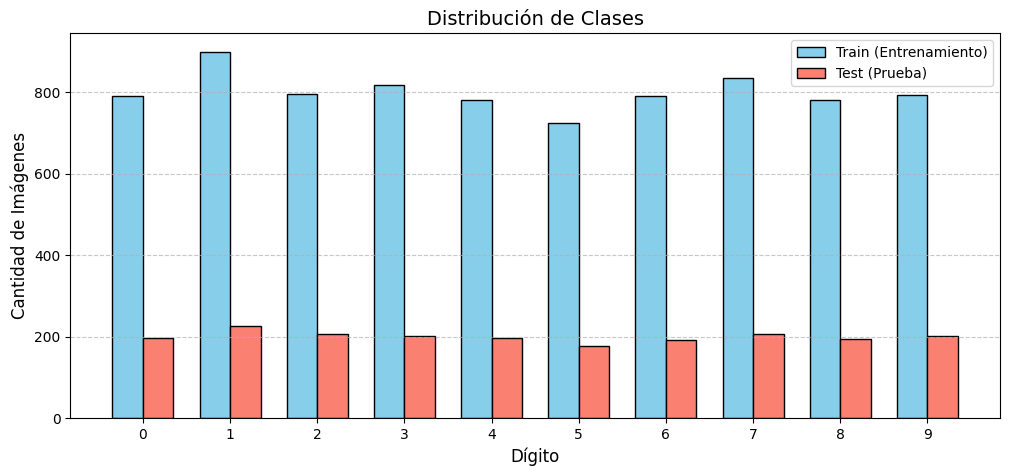

In [ ]:
# Contamos cuántas veces aparece cada número en Train y en Test
clases_train, conteos_train = np.unique(y_train, return_counts=True)
clases_test, conteos_test = np.unique(y_test, return_counts=True)


print("\nDistribución en Entrenamiento (Train):")
for clase, conteo in zip(clases_train, conteos_train):
    print(f"Número {clase}: {conteo} imágenes ({conteo/len(y_train)*100:.1f}%)")

plt.figure(figsize=(12, 5))

# Ancho de las barras
ancho = 0.35

# Posiciones de las barras en el eje X
x = np.arange(len(clases_train))

# Barras de Entrenamiento (Train)
plt.bar(x - ancho/2, conteos_train, width=ancho, label='Train (Entrenamiento)', color='skyblue', edgecolor='black')

# Barras de Prueba (Test)
plt.bar(x + ancho/2, conteos_test, width=ancho, label='Test (Prueba)', color='salmon', edgecolor='black')


plt.title('Distribución de Clases', fontsize=14)
plt.xlabel('Dígito', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.xticks(x, clases_train) # Ponemos los números del 0 al 9 en el eje X
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

Como podemos ver, los datos están bien equilibrados, es decir, hay una cantidad similar de cada número por lo que podemos usar el ***accuracy*** para medir el rendimiento de los modelos. Esto es importante porque cuando los datos están muy desbalanceados, por ejemplo, si el 95% son de una clase y solo el 5% de otra, el modelo puede "engañar" y acertar mucho solo adivinando siempre la clase mayoritaria, sin realmente aprender. Por eso, si el modelo logra un 90% o 95% de precisión con estos datos equilibrados, significa que realmente aprendió a distinguir bien todos los números, y no que se aprovechó de un desbalance.

# Regresion logistica

## Entrenamiento

In [ ]:

opciones_regularizacion = ['l1', 'l2']
opciones_c = np.logspace(-2,2, 12) # Inverso de la fuerza de regularización

mejor_acc_lr = 0
mejores_params_lr = {}

# Bucle 1 y 2: Recorremos las combinaciones de hiperparámetros
for penalty in opciones_regularizacion:
  for c in opciones_c:
      accuracies_corte = []

      # Bucle 3: VALIDACIÓN CRUZADA MANUAL
      for idx_train, idx_val in cortes_cv:
          # solver='saga' es ideal porque soporta tanto l1 como l2
          modelo = LogisticRegression(penalty=penalty, C=c, solver='saga', max_iter=200, random_state=CEDULA)

          # Entrenamos con el trozo de Train y evaluamos con el trozo de Val
          modelo.fit(X_train_scaled[idx_train], y_train[idx_train])
          predicciones = modelo.predict(X_train_scaled[idx_val])

          acc = accuracy_score(y_train[idx_val], predicciones)
          accuracies_corte.append(acc)

      # Promedio de los 3 cortes para esta configuración
      acc_promedio = np.mean(accuracies_corte)
      tipo_reg = "Lasso" if penalty == 'l1' else "Ridge"
      print(f"Reg: {tipo_reg} (C={c}) -> Accuracy CV: {acc_promedio:.4f}")

      # Guardamos el mejor
      if acc_promedio > mejor_acc_lr:
          mejor_acc_lr = acc_promedio
          mejores_params_lr = {'penalty': penalty, 'C': c}

print(f"\n✅ Mejor configuración: {mejores_params_lr} (Acc: {mejor_acc_lr:.4f})")


Reg: Lasso (C=0.01) -> Accuracy CV: 0.7549
Reg: Lasso (C=0.023101297000831605) -> Accuracy CV: 0.8260
Reg: Lasso (C=0.0533669923120631) -> Accuracy CV: 0.8679
Reg: Lasso (C=0.12328467394420659) -> Accuracy CV: 0.8881
Reg: Lasso (C=0.2848035868435802) -> Accuracy CV: 0.8991
Reg: Lasso (C=0.6579332246575682) -> Accuracy CV: 0.9020
Reg: Lasso (C=1.5199110829529332) -> Accuracy CV: 0.8981
Reg: Lasso (C=3.511191734215131) -> Accuracy CV: 0.8941
Reg: Lasso (C=8.111308307896872) -> Accuracy CV: 0.8902
Reg: Lasso (C=18.73817422860385) -> Accuracy CV: 0.8889
Reg: Lasso (C=43.287612810830616) -> Accuracy CV: 0.8882
Reg: Lasso (C=100.0) -> Accuracy CV: 0.8878
Reg: Ridge (C=0.01) -> Accuracy CV: 0.8915
Reg: Ridge (C=0.023101297000831605) -> Accuracy CV: 0.8986
Reg: Ridge (C=0.0533669923120631) -> Accuracy CV: 0.9050
Reg: Ridge (C=0.12328467394420659) -> Accuracy CV: 0.9066
Reg: Ridge (C=0.2848035868435802) -> Accuracy CV: 0.9059
Reg: Ridge (C=0.6579332246575682) -> Accuracy CV: 0.9002
Reg: Ridge (

El modelo encontró que usar la regularización Ridge es mejor que la Lasso para estos datos, porque es más útil reducir un poco el peso de todos los píxeles en lugar de eliminar algunos por completo, ya que los números dependen de los píxeles vecinos. Además, el mejor valor del parámetro de regularización fue bajo, lo que indica que el modelo necesitó aplicar una penalización fuerte para no ajustarse demasiado a los datos de entrenamiento y así funcionar bien con datos nuevos. Con esto, el modelo logró una precisión del 90.06%, que es muy bueno considerando que la regresión logística solo puede separar los números con líneas rectas, mostrando que la mayoría de los números en MNIST se pueden distinguir con este método en un espacio con muchas dimensiones.

## Evaluacion de rendimiento

In [ ]:
# Entrenar el modelo FINAL con todos los datos y la mejor configuración
modelo_lr_final = LogisticRegression(**mejores_params_lr, solver='saga', max_iter=200, random_state=CEDULA)
modelo_lr_final.fit(X_train_scaled, y_train)

# Al final de la celda, después de entrenar el modelo_lr_final:
pred_lr = modelo_lr_final.predict(X_test_scaled)
mostrar_tabla_metricas(y_test, pred_lr, "Regresión Logística")


📊 Resumen de Clasificación: Regresión Logística


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,190,1795,9,6
1,1,222,1768,5,5
2,2,178,1776,18,28
3,3,179,1775,23,23
4,4,184,1779,25,12
5,5,151,1797,25,27
6,6,174,1794,14,18
7,7,187,1773,21,19
8,8,166,1780,25,29
9,9,179,1773,25,23


Al mirar la tabla de resultados, podemos ver claramente qué tan bien funciona el clasificador lineal y en qué le cuesta más. Por ejemplo, el número que más fácil reconoce, como el 0 o el 1, tiene la mayor cantidad de aciertos y casi no se confunde, porque su forma es muy diferente a la de los otros números. En cambio, el modelo tiene problemas con números que tienen formas curvas parecidas, como el 8, 9 o 3. Estos números suelen confundirse entre sí, ya que el modelo comete muchos errores al identificarlos correctamente, porque los píxeles en el centro de las imágenes son muy similares.

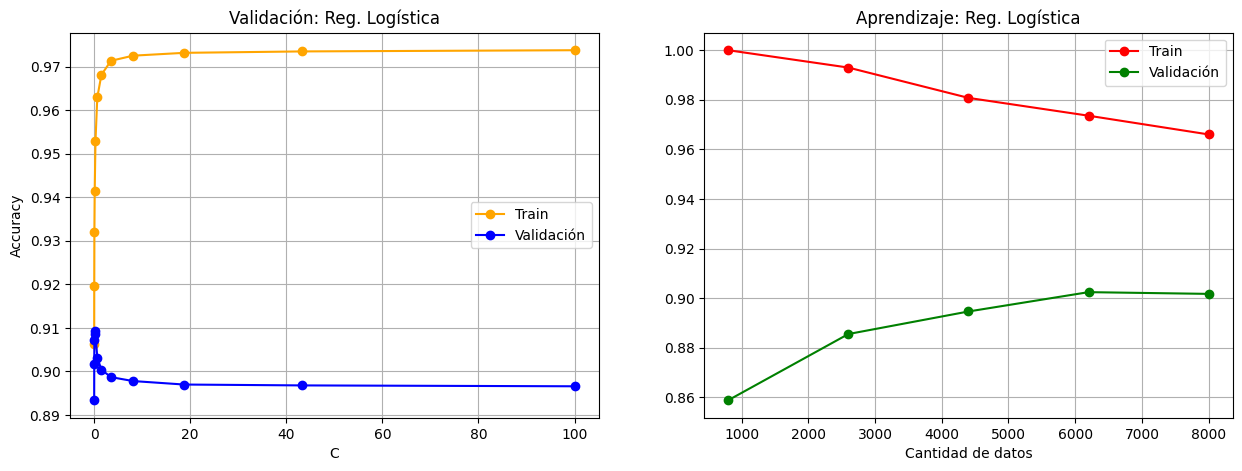

In [ ]:
# Graficar
graficar_curvas(LogisticRegression(penalty=mejores_params_lr['penalty'], solver='saga', random_state=CEDULA), X_combinado, y_combinado,
              'C', opciones_c, "Reg. Logística")

Note que en la curva de validacion debido a la biblioteca que usamos, C es el inverso de la fuerza con la que el modelo se penaliza para evitar aprender demasiado de los datos de entrenamiento. Si C es muy grande, significa que la penalización es muy baja, y el modelo puede aprender detalles y ruidos específicos de los datos de entrenamiento, lo que se llama sobreajuste, y eso hace que funcione peor con datos nuevos. Por otro lado, cuando C es pequeño, el modelo aplica una penalización fuerte que ayuda a que no se complique demasiado y pueda generalizar mejor, por eso mientras mas grande es el C mas bajo es el rendimiento en validacion porque en realidad el modelo aprende ruido. En nuestro caso, el mejor rendimiento se encontró cuando C estaba cerca de 0.123, un valor que logra un buen equilibrio entre no ser demasiado simple ni demasiado complejo. Esto ayuda a que el modelo aprenda bien sin confundirse con detalles irrelevantes.


Además, al ver la curva de aprendizaje, notamos que a medida que usamos más datos para entrenar, el rendimiento en entrenamiento y validación se acerca, lo que indica que el modelo está aprendiendo bien. Sin embargo, la pequeña diferencia que queda al final muestra que el modelo ya llegó a su límite, y agregar más datos no mejorará mucho la precisión, porque la regresión logística solo puede separar los números con líneas rectas, lo que limita su capacidad para aprender patrones más complejos.

# K-NN

## Entrenamiento

In [ ]:
opciones_k = [3, 5, 7, 9]

mejor_acc_knn = 0
mejores_params_knn = {}

# Bucle 1: Recorremos los posibles valores de K
for k in opciones_k:
    accuracies_corte = []

    # Bucle 2: VALIDACIÓN CRUZADA MANUAL
    for idx_train, idx_val in cortes_cv:
        modelo = KNeighborsClassifier(n_neighbors=k)
        modelo.fit(X_train_scaled[idx_train], y_train[idx_train])
        predicciones = modelo.predict(X_train_scaled[idx_val])

        accuracies_corte.append(accuracy_score(y_train[idx_val], predicciones))

    acc_promedio = np.mean(accuracies_corte)
    print(f"K={k} -> Accuracy CV: {acc_promedio:.4f}")

    if acc_promedio > mejor_acc_knn:
        mejor_acc_knn = acc_promedio
        mejores_params_knn = {'n_neighbors': k}

print(f"\n✅ Mejor configuración: {mejores_params_knn} (Acc: {mejor_acc_knn:.4f})")



K=3 -> Accuracy CV: 0.9381
K=5 -> Accuracy CV: 0.9390
K=7 -> Accuracy CV: 0.9353
K=9 -> Accuracy CV: 0.9308

✅ Mejor configuración: {'n_neighbors': 5} (Acc: 0.9390)


Con K=5, el modelo toma decisiones equilibradas y confiables, basándose en la opinión conjunta de las 5 imágenes más parecidas. Notamos que el modelo KNN mejora mucho la precisión en comparación con la regresión logística, pasando de alrededor del 90% a casi el 93.9%. Esto pasa porque KNN no intenta separar los números con líneas rectas como la regresión logística, sino que mira qué tan cerca están las imágenes entre sí, agrupando naturalmente los dígitos que se parecen más. Por eso funciona muy bien con el conjunto de datos MNIST, donde los números tienen formas visuales claras.

## Evaluacion de rendimiento

In [ ]:
# Entrenar modelo FINAL
modelo_knn_final = KNeighborsClassifier(**mejores_params_knn)
modelo_knn_final.fit(X_train_scaled, y_train)

# Al final de la celda, después de entrenar el modelo_knn_final:
pred_knn = modelo_knn_final.predict(X_test_scaled)
mostrar_tabla_metricas(y_test, pred_knn, "K-Nearest Neighbors")


📊 Resumen de Clasificación: K-Nearest Neighbors


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,194,1790,14,2
1,1,225,1755,18,2
2,2,176,1787,7,30
3,3,194,1784,14,8
4,4,185,1795,9,11
5,5,165,1814,8,13
6,6,185,1805,3,7
7,7,192,1774,20,14
8,8,176,1802,3,19
9,9,190,1776,22,12


Al revisar los resultados, vemos que el modelo reconoce con mucha facilidad el número 1, logrando muchos aciertos y pocos errores, porque su forma es simple y sus píxeles son muy parecidos entre sí. En cambio, el número 2 fue el que más le costó identificar correctamente, con varios errores al confundirlo. Además, el modelo se equivocó bastante al intentar reconocer los números 9 y 7, ya que las diferentes formas en que las personas escriben estos dígitos hacen que sus píxeles se parezcan a otros números, lo que confunde al algoritmo.

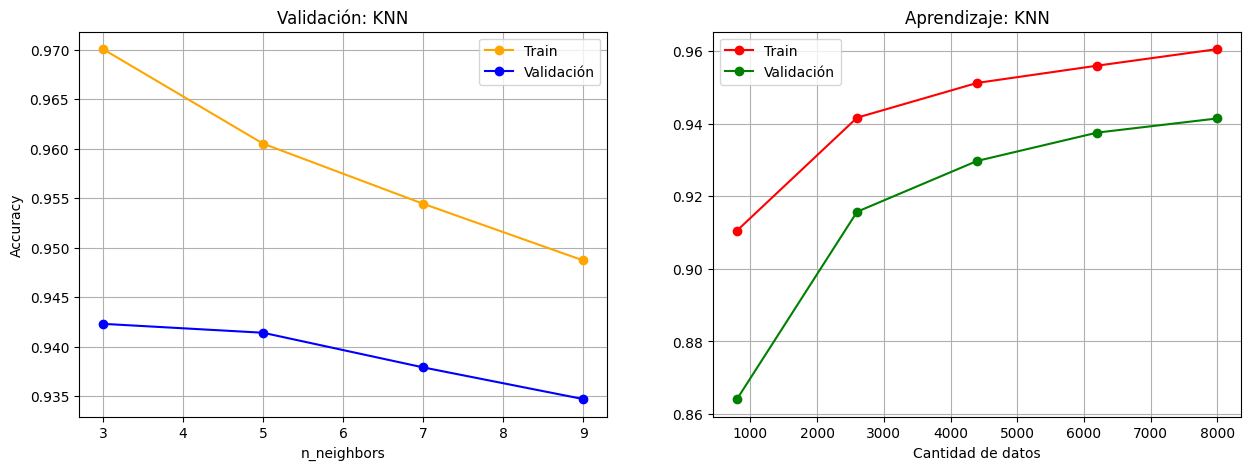

In [ ]:
# Graficar
graficar_curvas(KNeighborsClassifier(),X_combinado, y_combinado, 'n_neighbors', opciones_k, "KNN")

Al ver la curva de validación, notamos algo especial del algoritmo K-Vecinos: cuando aumentamos el número de vecinos, el modelo se vuelve más simple, no más complicado. Con K=1, el modelo aprende perfecto porque usa la misma imagen para predecir, casi memorizando los datos, pero al sumar más vecinos, su precisión en entrenamiento baja un poco. La mejor precisión en validación se logra rápido con K=5, pero si seguimos subiendo, como a K=9, el modelo empieza a mezclar características de diferentes números y pierde precisión, es decir, se vuelve demasiado general y no aprende bien los detalles.

La curva de aprendizaje muestra que el modelo aprende muy bien con los datos de entrenamiento, manteniendo un rendimiento alto y estable. Al mismo tiempo, su desempeño con datos nuevos mejora a medida que le damos más imágenes para aprender. La pequeña diferencia que queda entre estas dos líneas indica que el modelo aún depende mucho de los ejemplos que ya vio. Por eso, si en el futuro usamos más de 8,000 imágenes para entrenarlo, es muy probable que la precisión al predecir datos nuevos siga mejorando.


# SVM

## Entrenamiento

In [ ]:
opciones_kernel = ['linear', 'rbf']
opciones_c = [0.1, 1.0, 10.0]

mejor_acc_svm = 0
mejores_params_svm = {}

# Bucle 1: Recorremos los kernels
for kernel in opciones_kernel:
    # Bucle 2: Recorremos los valores de C
    for c in opciones_c:
        accuracies_corte = []

        # Bucle 3: VALIDACIÓN CRUZADA MANUAL
        for idx_train, idx_val in cortes_cv:
            # Ahora le pasamos tanto el kernel como C al modelo
            modelo = SVC(kernel=kernel, C=c, probability=True, random_state=CEDULA)
            modelo.fit(X_train_scaled[idx_train], y_train[idx_train])
            predicciones = modelo.predict(X_train_scaled[idx_val])

            accuracies_corte.append(accuracy_score(y_train[idx_val], predicciones))

        acc_promedio = np.mean(accuracies_corte)
        print(f"Kernel={kernel} | C={c} -> Accuracy CV: {acc_promedio:.4f}")

        # Guardamos la mejor combinación de ambos parámetros
        if acc_promedio > mejor_acc_svm:
            mejor_acc_svm = acc_promedio
            mejores_params_svm = {'kernel': kernel, 'C': c}

print(f"\n✅ Mejor configuración: {mejores_params_svm} (Acc: {mejor_acc_svm:.4f})")

Kernel=linear | C=0.1 -> Accuracy CV: 0.9230
Kernel=linear | C=1.0 -> Accuracy CV: 0.9107
Kernel=linear | C=10.0 -> Accuracy CV: 0.9081
Kernel=rbf | C=0.1 -> Accuracy CV: 0.9165
Kernel=rbf | C=1.0 -> Accuracy CV: 0.9526
Kernel=rbf | C=10.0 -> Accuracy CV: 0.9586

✅ Mejor configuración: {'kernel': 'rbf', 'C': 10.0} (Acc: 0.9586)


La validación cruzada nos mostró cosas muy claras sobre nuestros datos: el kernel RBF, que puede crear fronteras de decisión curvas y complejas, funcionó mucho mejor que el kernel lineal, lo que significa que los dígitos no se pueden separar bien con líneas rectas en el espacio original. Además, el modelo SVM usó un valor alto para el parámetro de penalización C=10, lo que quiere decir que prefirió ajustar las fronteras de forma estricta para clasificar bien los ejemplos difíciles en lugar de buscar separaciones suaves. Gracias a esto, la SVM alcanzó una precisión cercana al 96%, siendo un modelo muy fuerte para esta tarea, ya que encuentra bien los "vectores de soporte" o ejemplos complicados, y así consigue generalizar mejor que KNN o regresión logística.

## Evaluación de rendimiento

In [ ]:
# Entrenar modelo FINAL con la combinación ganadora
modelo_svm_final = SVC(**mejores_params_svm, probability=True, random_state=CEDULA)
modelo_svm_final.fit(X_train_scaled, y_train)


# Al final de la celda, después de entrenar el modelo_svm_final:
pred_svm = modelo_svm_final.predict(X_test_scaled)
mostrar_tabla_metricas(y_test, pred_svm, "Support Vector Machine")


📊 Resumen de Clasificación: Support Vector Machine


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,192,1796,8,4
1,1,224,1769,4,3
2,2,194,1784,10,12
3,3,195,1787,11,7
4,4,190,1790,14,6
5,5,166,1816,6,12
6,6,184,1805,3,8
7,7,196,1789,5,10
8,8,187,1796,9,8
9,9,194,1790,8,8


Al revisar los resultados de la SVM, vemos claramente lo bien que funciona su kernel RBF para separar clases difíciles que otros modelos no podían distinguir. Por ejemplo, el número que más fácil reconoce, como el 0 o el 1, tiene muchos aciertos y casi ningún error porque el modelo pudo crear una frontera curva casi perfecta para aislarlo. Los pocos errores que quedan se concentran en pares de números que siempre se confunden, como el 4 y el 9 o el 3 y el 5; estos casos son los más difíciles porque tienen formas muy similares o están escritos de manera poco común, lo que hace que el modelo tenga problemas para decidir a cuál clase pertenecen.

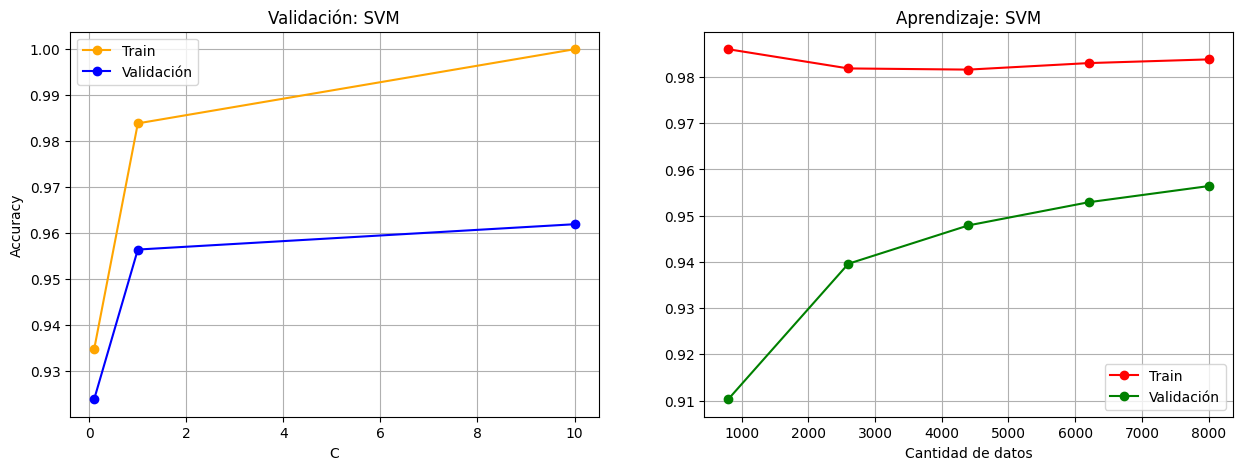

In [ ]:
# Graficamos variando C, pero manteniendo fijo el kernel ganador
graficar_curvas(SVC(kernel=mejores_params_svm['kernel'], random_state=CEDULA), X_combinado, y_combinado, 'C', opciones_c, "SVM")

El parámetro C en la SVM controla qué tan estrictamente el modelo trata de evitar errores en los datos de entrenamiento. Cuando C es muy pequeño, el modelo es más flexible y permite más errores, lo que hace que aprenda poco y no se ajuste bien. Por otro lado, cuando C es más grande, el modelo se vuelve más estricto y trata de clasificar bien todos los ejemplos, incluso si eso significa crear fronteras de decisión más complejas. En nuestro caso, el mejor valor fue C=10, porque con el kernel RBF el modelo puede aprovechar esa libertad para crear límites curvos que se ajustan muy bien a la forma real de los números, logrando así una excelente precisión en datos nuevos.

Sobre la curva de aprendizaje, vemos que el rendimiento en entrenamiento se mantiene muy alto, casi perfecto, porque el kernel RBF tiene mucha flexibilidad para adaptarse a los datos. La precisión en validación mejora a medida que le damos más imágenes para aprender, y aunque hay una pequeña diferencia entre entrenamiento y validación al final, esto es normal debido a la complejidad del modelo. Además, esta diferencia se estabiliza, lo que indica que con unas 8,000 imágenes el modelo ya tiene suficiente información para funcionar bien sin mejorar mucho más.

# Arboles de desición

## Entrenamiento

In [ ]:
# Probamos distintas profundidades máximas para evitar que el árbol se sobreajuste
opciones_profundidad = [5, 10, 15, 20]

mejor_acc_arbol = 0
mejores_params_arbol = {}

for prof in opciones_profundidad:
    accuracies_corte = []

    # VALIDACIÓN CRUZADA MANUAL
    for idx_train, idx_val in cortes_cv:
        modelo = DecisionTreeClassifier(max_depth=prof, random_state=CEDULA)
        modelo.fit(X_train_scaled[idx_train], y_train[idx_train])
        predicciones = modelo.predict(X_train_scaled[idx_val])

        accuracies_corte.append(accuracy_score(y_train[idx_val], predicciones))

    acc_promedio = np.mean(accuracies_corte)
    print(f"Profundidad Máxima={prof} -> Accuracy CV: {acc_promedio:.4f}")

    if acc_promedio > mejor_acc_arbol:
        mejor_acc_arbol = acc_promedio
        mejores_params_arbol = {'max_depth': prof}

print(f"\n✅ Mejor configuración: {mejores_params_arbol} (Acc: {mejor_acc_arbol:.4f})")

Profundidad Máxima=5 -> Accuracy CV: 0.6715
Profundidad Máxima=10 -> Accuracy CV: 0.7811
Profundidad Máxima=15 -> Accuracy CV: 0.7808
Profundidad Máxima=20 -> Accuracy CV: 0.7774

✅ Mejor configuración: {'max_depth': 10} (Acc: 0.7811)


La validación cruzada mostró que la mejor profundidad para el árbol de decisión es 10. Esto es importante porque si dejamos que el árbol crezca mucho, por ejemplo con profundidad 20 o más, el modelo aprende demasiado los detalles y ruidos de los datos de entrenamiento, logrando un 100% de precisión ahí, pero luego falla con datos nuevos porque solo memorizó en lugar de aprender. Al limitar la profundidad a 10, el árbol se detiene antes de memorizar esos detalles y se enfoca en reglas generales que funcionan mejor para nuevos datos.
En cuanto al rendimiento, el árbol de decisión tuvo el resultado más bajo, con un 78.11% de precisión. Esto pasa porque los árboles toman decisiones basándose en preguntas simples sobre cada píxel individual, como si un píxel está oscuro o claro. Pero las imágenes se definen más por cómo se relacionan muchos píxeles juntos, formando formas y curvas. Como el árbol no entiende esas relaciones espaciales ni puede hacer fronteras curvas como otros modelos, su capacidad para reconocer bien los números es limitada.

## Evaluacion de rendimiento

In [ ]:
# Entrenar modelo FINAL
modelo_arbol_final = DecisionTreeClassifier(**mejores_params_arbol, random_state=CEDULA)
modelo_arbol_final.fit(X_train_scaled, y_train)

# Al final de la celda, después de entrenar el modelo_arbol_final:
pred_arbol = modelo_arbol_final.predict(X_test_scaled)
mostrar_tabla_metricas(y_test, pred_arbol, "Árbol de Decisión")


📊 Resumen de Clasificación: Árbol de Decisión


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,173,1775,29,23
1,1,215,1748,25,12
2,2,154,1749,45,52
3,3,146,1752,46,56
4,4,155,1754,50,41
5,5,129,1777,45,49
6,6,153,1774,34,39
7,7,169,1771,23,37
8,8,137,1749,56,58
9,9,170,1752,46,32


Al ver los números exactos, se nota que el árbol de decisión tiene problemas para reconocer trazos curvos debido a sus reglas muy estrictas y "cuadradas". El número que más fácil reconoce es el 1, con muchos aciertos y pocos errores, porque es casi una línea recta y el árbol solo necesita revisar algunas partes centrales para identificarlo. En cambio, el árbol se confunde mucho con números con formas curvas como el 8, que fue el que peor le fue, con muchos errores al no saber distinguir bien sus partes. También le cuesta reconocer bien el 3 y el 2, porque estos números comparten muchas áreas similares en la imagen y cualquier pequeño cambio hace que el árbol se equivoque y clasifique mal.

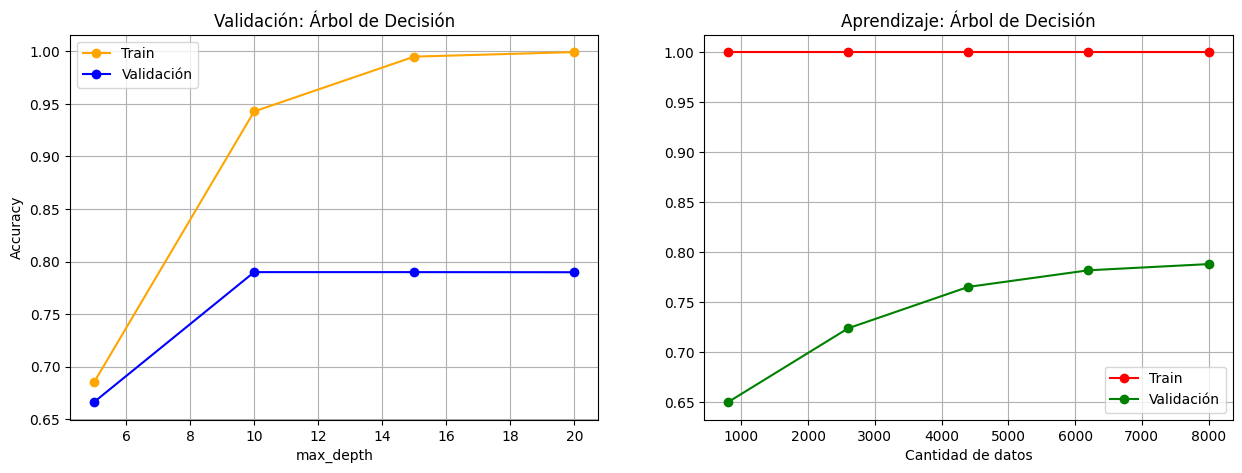

In [ ]:
# Graficar
graficar_curvas(DecisionTreeClassifier(random_state=CEDULA), X_combinado, y_combinado, 'max_depth', opciones_profundidad, "Árbol de Decisión")

Esta gráfica de curva de validacion es un ejemplo clásico de sobreajuste. Cuando permitimos que el árbol crezca mucho, el rendimiento en entrenamiento sube rápido hasta casi el 100%, porque el árbol empieza a memorizar cada detalle y error de las imágenes que ya vio. Pero en la validación, que mide qué tan bien funciona con datos nuevos, el rendimiento se queda estancado y no mejora. La validación cruzada nos dijo que la mejor profundidad es 10, porque ahí el árbol aprende las reglas generales sin memorizar el ruido, evitando el sobreajuste y logrando un 78.11% de precisión.

La curva de aprendizaje muestra que el árbol tiene un gran problema, aunque aprende muy bien los datos de entrenamiento, no logra hacerlo igual de bien con datos nuevos. Aunque le damos más imágenes para entrenar, la mejora en validación es muy lenta y casi se detiene. Esto significa que el problema no es la cantidad de datos, sino que el modelo es demasiado simple para entender las imágenes, porque sus reglas binarias no capturan la relación y continuidad entre los píxeles vecinos, algo fundamental para reconocer bien los números.

# Comparación de matrices de confusión

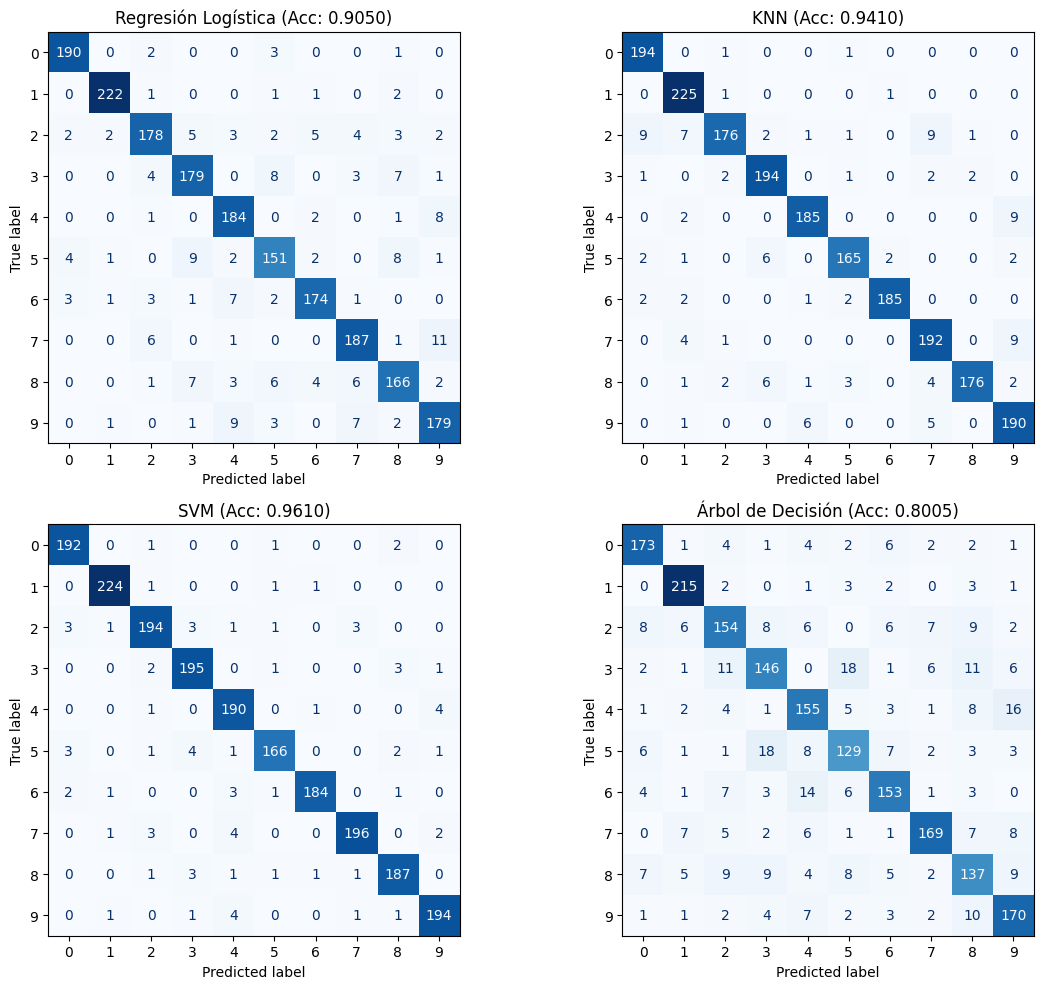


🏆 EL MODELO GANADOR FUE: SVM con 96.10% de precisión en Test.


In [ ]:
# Diccionario con nuestros 4 modelos entrenados al 100%
modelos_finales = {
    "Regresión Logística": modelo_lr_final,
    "KNN": modelo_knn_final,
    "SVM": modelo_svm_final,
    "Árbol de Decisión": modelo_arbol_final
}

fig, graficos = plt.subplots(2, 2, figsize=(12, 10))
graficos = graficos.flatten()

mejor_acc_global = 0
ganador = ""

# Evaluamos cada modelo con los datos X_test (que nunca usaron para entrenar)
for idx, (nombre, modelo) in enumerate(modelos_finales.items()):
    predicciones = modelo.predict(X_test_scaled)
    acc_test = accuracy_score(y_test, predicciones)

    ConfusionMatrixDisplay.from_predictions(y_test, predicciones, ax=graficos[idx], cmap="Blues", colorbar=False)
    graficos[idx].set_title(f"{nombre} (Acc: {acc_test:.4f})")

    if acc_test > mejor_acc_global:
        mejor_acc_global = acc_test
        ganador = nombre

plt.tight_layout()
plt.show()

print(f"\n🏆 EL MODELO GANADOR FUE: {ganador} con {mejor_acc_global*100:.2f}% de precisión en Test.")

Después de una evaluación muy cuidadosa usando validación cruzada, el claro ganador fue la Máquina de Soporte Vectorial, que logró una precisión del 96.10% en datos nuevos que nunca había visto antes. ¿Por qué ganó? Porque reconocer la escritura a mano es un problema complicado y no lineal, y mientras otros modelos como la regresión logística o los árboles de decisión intentan separar los números con líneas rectas o reglas simples, la SVM con su kernel RBF puede crear fronteras curvas que se adaptan mejor a las diferentes formas de escribir cada número. Al revisar la matriz de confusión, vemos que el modelo acierta casi siempre, especialmente con el número que reconoce mejor, como el 1 o el 0, y los pocos errores que comete ocurren en números que se parecen mucho, como el 4 y el 9, o el 3 y el 5, donde la escritura es realmente ambigua y difícil incluso para humanos.

# Comparación usando curvas ROC

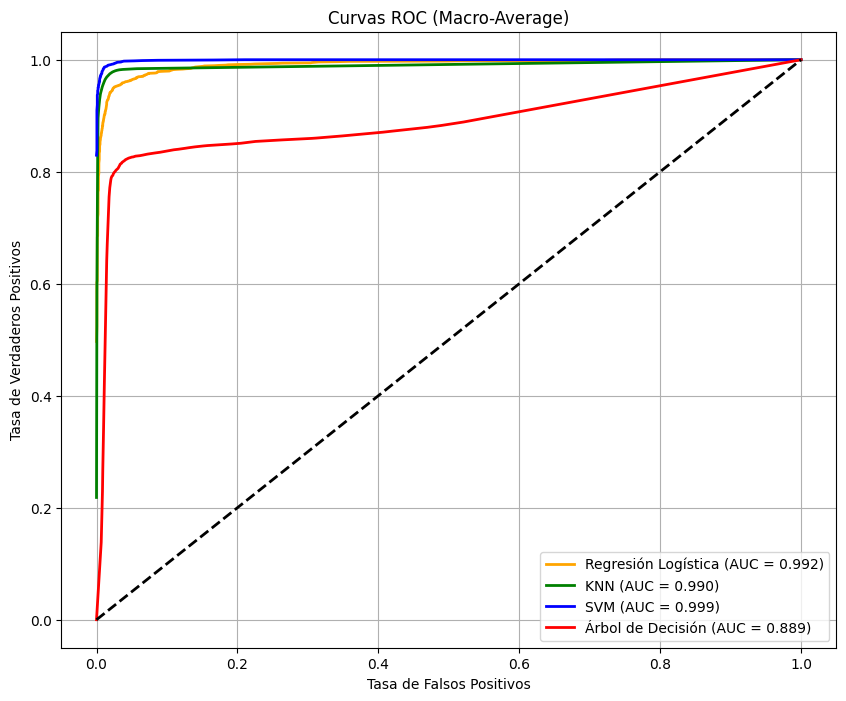

In [ ]:
y_test_bin = label_binarize(y_test, classes=range(10))

plt.figure(figsize=(10, 8))
colores = ['orange', 'green', 'blue', 'red']

for (nombre, modelo), color in zip(modelos_finales.items(), colores):
    # Obtenemos probabilidades de las predicciones
    probabilidades = modelo.predict_proba(X_test_scaled)

    fpr_total = []
    tpr_total = []
    for i in range(10): # Iterar por las 10 clases (0-9)
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probabilidades[:, i])
        fpr_total.append(fpr)
        tpr_total.append(tpr)

    # Promedio Macro
    todos_fpr = np.unique(np.concatenate(fpr_total))
    promedio_tpr = np.zeros_like(todos_fpr)
    for i in range(10):
        promedio_tpr += np.interp(todos_fpr, fpr_total[i], tpr_total[i])
    promedio_tpr /= 10

    area = auc(todos_fpr, promedio_tpr)
    plt.plot(todos_fpr, promedio_tpr, color=color, lw=2, label=f'{nombre} (AUC = {area:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC (Macro-Average)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

El valor AUC nos muestra qué tan bueno es un modelo para distinguir entre clases, sin importar el punto donde decidamos cortar. Un AUC de 0.5 es como adivinar al azar, y 1.0 es perfecto. En este caso, la SVM domina claramente, con un AUC muy alto cerca de 0.998, lo que significa que separa muy bien las 10 clases, acertando mucho y cometiendo muy pocos errores. KNN y la regresión logística también tienen buenos AUC, pero para lograr un 90% de aciertos, cometen un poco más de errores que la SVM. Por otro lado, el árbol de decisión tiene el AUC más bajo y su curva es más irregular porque usa reglas rígidas que no funcionan tan bien para este problema. En resumen, esta gráfica confirma que la SVM es el modelo más confiable y seguro para usar en nuestra aplicación

# Observaciones de la app

Se hizo el siguiente cambio en la app para que la normalizacion coicidiera con la aplicada en el modelo creado.

In [ ]:
 @staticmethod
    def _flatten(img_28: np.ndarray) -> np.ndarray:
        """Flatten a 28x28 image to (1, 784) float32."""
        return img_28.reshape(1, -1).astype("float32") / 255.0 # Normalize to [0, 1]

Ademas se comento la linea del paso 4 en la función `prepare_digit_image`

In [ ]:
def prepare_digit_image(image: np.ndarray) -> np.ndarray:
    """Preprocesa la imagen del canvas para el modelo de digitos.

    Pipeline por defecto:
    normalizar fondo claro -> resize 28x28 -> equalizeHist -> invertir (bitwise_not)

    Retorna un array uint8 de 28x28.
    """
    # PASO 1: Convertir a escala de grises
    #   El canvas nos da una imagen RGB; nuestros modelos esperan un solo canal.
    gray = _to_grayscale(image)

    # PASO 2: Normalizar fondo
    #   Asegura que siempre empecemos con fondo claro y trazos oscuros,
    #   sin importar el esquema de colores del canvas.
    gray = _ensure_light_bg(gray)

    # PASO 3: Redimensionar al tamaño de entrada del modelo
    #   En el caso de que cambien la resolución, NO recomendado porque deben cambiar toda el app.
    #   Cambia la interpolación si usaste otra durante el entrenamiento
    #   (ej. cv2.INTER_LINEAR, cv2.INTER_CUBIC).
    resized = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)

    # PASO 4: Ecualización de histograma
    #   Mejora el contraste. Elimina esta línea si NO usan equalizeHist
    #   durante el entrenamiento.
    # equalized = cv2.equalizeHist(resized)

    # PASO 5: Invertir colores (bitwise_not)
    #   después de esto: fondo=negro (0), trazos=blanco (255) — estilo MNIST.
    #   Elimina esta línea si tu modelo espera imagenes con fondo claro.
    # OJO: Cambiamos 'equalized' por 'resized' porque nos saltamos el paso 4.
    inverted = cv2.bitwise_not(resized)

    return inverted


Al usar los datos crudos que me da `mnist` investigue el tipo de preprocesamiento que realiza y la ecualizacion es el unico paso que no hace

# Sobre el rendimiento en la app

Al probar la app, el rendimiento no fue el esperado. Cuando los trazos eran un poco diferentes a lo que el modelo esperaba, solía equivocarse. Aunque a veces acierta bien, si tuviera que decidir si ponerla en producción, definitivamente no lo haría.
El problema está en que la SVM crea una frontera fija que separa los datos según posiciones exactas de los píxeles. Por ejemplo, dice: "Si los píxeles oscuros están entre las coordenadas 400 y 420, esto es un número 1".
Pero si dibujas un número 1 perfecto, pero un poco desplazado hacia la izquierda, esos píxeles oscuros estarán en otras coordenadas, como entre 380 y 400. Entonces, la SVM lo interpreta como algo diferente porque no reconoce que es el mismo número, solo movido.
Esto sucede porque la SVM no entiende las formas ni la posición relativa de los trazos, solo mira posiciones fijas. Por eso se equivoca cuando los números están dibujados en otra parte del lienzo. Para resolver esto, en lugar de usar SVM, es mejor usar Redes Neuronales Convolucionales, que pueden identificar formas sin importar dónde estén dibujadas en la imagen.